# Visualising DOSCAR
To see and visualise the DOSCAR files available

## SETUP

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

doscar_files_dir=os.path.join(os.getcwd(), 'DOSCAR_files')


### TOTAL DOS vs Energy Plot

In [24]:
# Loading data helper function
def load_total_dos(file_path):
    """
    Function to load and parse a DOSCAR file.

    Args:
        file_path(str): Path to the DOSCAR file

    Returns:
        energy (list): List of energy values
        total_dos (list): List of total DOS values
    """

    energy = []
    total_dos = []

    with open(file_path, 'r') as file:
        lines = file.readlines()

        # Extract NEDOS from 6th line, 3rd column
        nedos = int(lines[5].split()[2])

        # Skip the header (assumes the first 6 lines are header info)
        header_lines = 6

        for line in lines[header_lines:header_lines+nedos]:
            data = line.split()

            # Append energy and total DOS
            energy.append(float(data[0]))
            total_dos.append(float(data[1]))

    return energy, total_dos

def plot_total_dos(molecule_name, energy, total_dos):
    """
    Plots Total DOS vs Energy data
    
    Args:
        molecule_name (str): Name of the molecule
        energy (list): List of energy values
        total_dos (list): List of total DOS values
    """
    plt.figure(figsize=(10,6))
    plt.plot(energy, total_dos, label='Total_DOS')
    plt.xlabel('Energy (eV)')
    plt.ylabel('Density of States')
    plt.title(f'Total DOS vs Energy for {molecule_name}')
    plt.legend()
    plt.grid(True)
    plt.show()

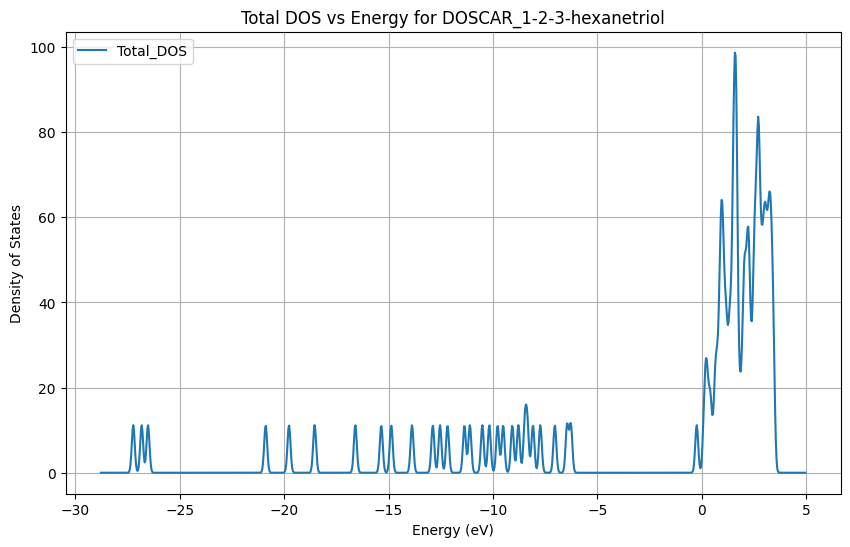

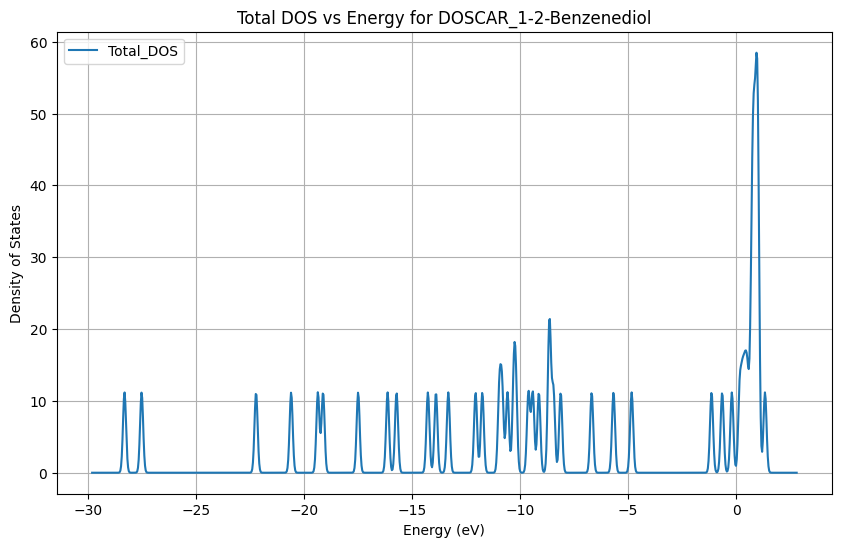

In [25]:
for folder in os.listdir(doscar_files_dir):
    folder_path = os.path.join(doscar_files_dir, folder)
    if os.path.isdir(folder_path):
        energy, total_dos = load_total_dos(os.path.join(folder_path, 'DOSCAR'))
        plot_total_dos(folder, energy, total_dos)

### Combined/Corrected DOS data


In [26]:
def load_orbital_data(file_path):
    """
    Loads orbital DOS data from a text file
    
    Args: 
        file_path (str): Path to the text file containing DOS data.

    Returns:
        data (ndarray): NumPy array of shape (N, 10), where N is the NEDOS
    """
    
    # Load data assuming 10 columns
    orbital_data = np.loadtxt(file_path)
    return orbital_data

def plot_orbital_data(molecule_name, orbital_data):
    """
    Plots the orbital data of the molecule
    
    Args:
        molecule_name (str): Name of the molecule
        orbital_data (ndarray): orbital DOS data of the molecule
    """
    # Obtain energy data from first column
    energy = orbital_data[:,0]

    # Setup orbital contributions
    orbitals = ['s', 
                'p_y', 
                'p_z',
                'p_x',
                'd_xy',
                'd_yz',
                'd_z2-r2',
                'd_xz',
                'd_x2-y2']
    
    orbital_DOS = orbital_data[:,1:]

    # Plot the data
    plt.figure(figsize=(12,8))

    for i, orbital in enumerate(orbitals):
        plt.plot(energy, orbital_DOS[:,i], label=f'{orbital}', linewidth=2)

    plt.xlabel('Energy (eV)', fontsize=14)
    plt.ylabel('DOS', fontsize=14)
    plt.title(f'DOS by Orbital for {molecule_name}', fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

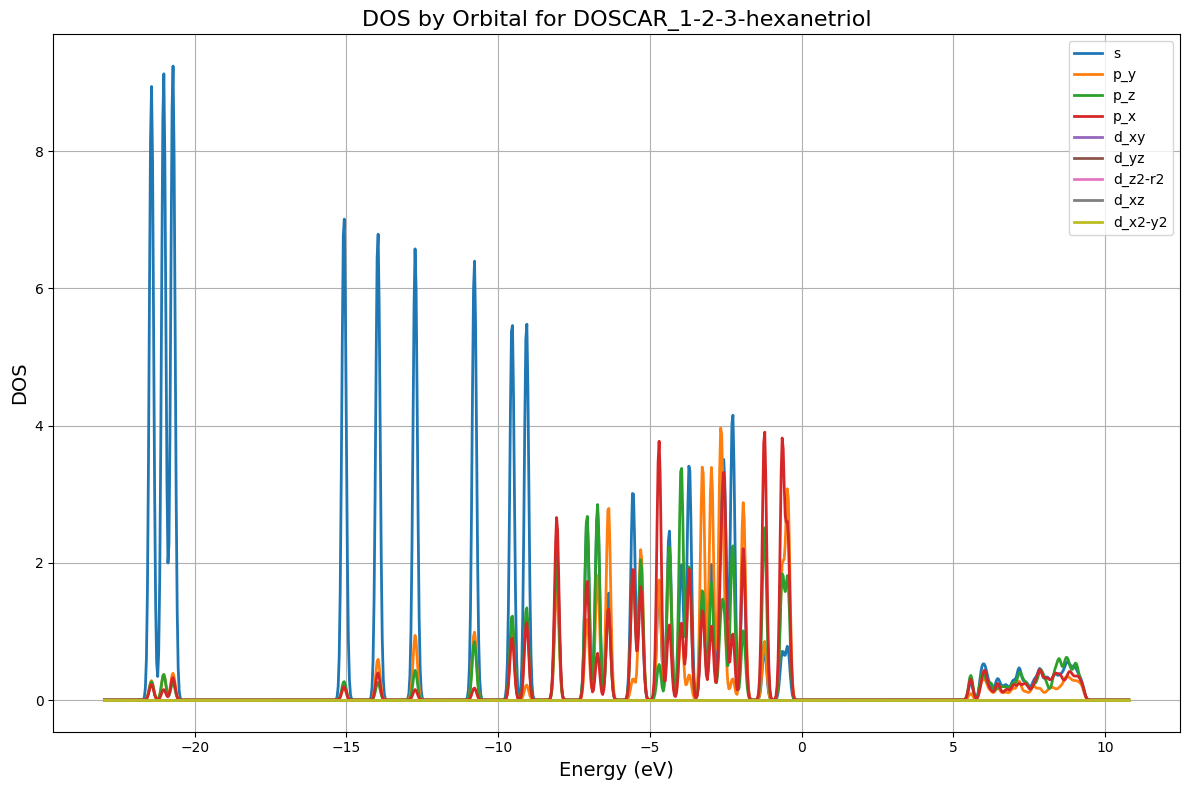

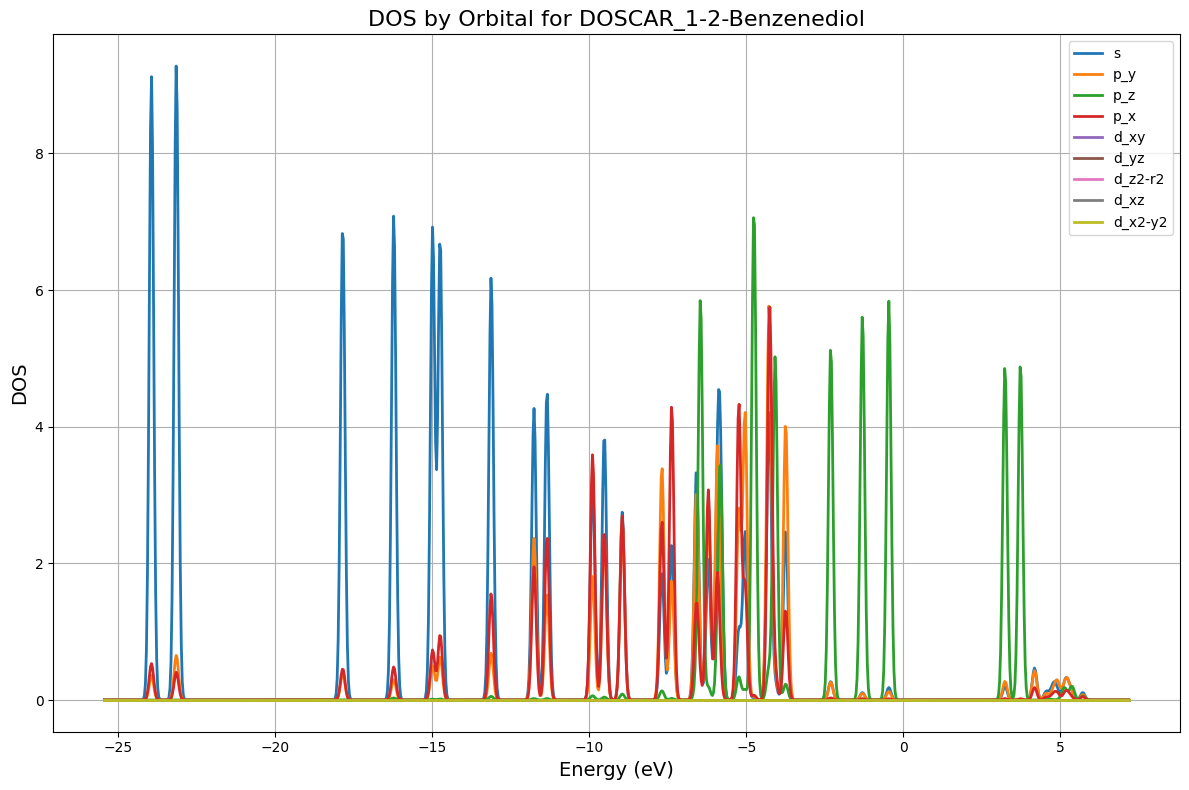

In [27]:
for folder in os.listdir(doscar_files_dir):
    folder_path = os.path.join(doscar_files_dir, folder)
    if os.path.isdir(folder_path):
        file_path = os.path.join(folder_path,'Separate_files','corrected_DOS_data.txt')
        orbital_data =load_orbital_data(file_path)
        plot_orbital_data(folder, orbital_data)